In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression , LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score ,confusion_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt 
from sklearn.preprocessing import LabelEncoder

In [2]:
SAD=pd.read_csv(r"C:\Users\nazis\Desktop\AI project\Sleep Analysis Dataset.csv")

In [3]:
X=SAD.drop(columns=['sleep_quality','sleep_needed_hours'])
Y=SAD['sleep_quality']
Z=SAD['sleep_needed_hours']

In [4]:
print(X.head())
print(X.tail())

   age  gender  sleep_hours  wakeup_time  screen_time  study_work_hours  \
0   67       0            6            5            4                 1   
1   24       1            8            9            5                 9   
2   52       0            8            8            4                 8   
3   46       0            9            9            4                 5   
4   31       1            7            6            2                 8   

   meals_count  
0            5  
1            5  
2            5  
3            2  
4            4  
      age  gender  sleep_hours  wakeup_time  screen_time  study_work_hours  \
1995   41       0            8            8            5                 7   
1996   58       0            9            9            5                 2   
1997   42       1            9           10            4                 5   
1998   50       1            8            9            5                 3   
1999   25       1            7            8            2 

In [5]:
print(Y.head())
print(Y.tail())

0    0
1    0
2    0
3    0
4    0
Name: sleep_quality, dtype: int64
1995    0
1996    0
1997    0
1998    0
1999    1
Name: sleep_quality, dtype: int64


In [6]:
print(Z.head())
print(Z.tail())

0    7
1    7
2    8
3    9
4    8
Name: sleep_needed_hours, dtype: int64
1995    8
1996    9
1997    9
1998    8
1999    7
Name: sleep_needed_hours, dtype: int64


In [7]:
print(Y,X,Z.shape)

0       0
1       0
2       0
3       0
4       0
       ..
1995    0
1996    0
1997    0
1998    0
1999    1
Name: sleep_quality, Length: 2000, dtype: int64       age  gender  sleep_hours  wakeup_time  screen_time  study_work_hours  \
0      67       0            6            5            4                 1   
1      24       1            8            9            5                 9   
2      52       0            8            8            4                 8   
3      46       0            9            9            4                 5   
4      31       1            7            6            2                 8   
...   ...     ...          ...          ...          ...               ...   
1995   41       0            8            8            5                 7   
1996   58       0            9            9            5                 2   
1997   42       1            9           10            4                 5   
1998   50       1            8            9            5      

In [8]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [9]:
X_train, X_test, Z_train, Z_test = train_test_split(X, Z, test_size=0.2, random_state=42)

In [10]:
class_scaler = StandardScaler()
X_train = class_scaler.fit_transform(X_train)
X_test = class_scaler.transform(X_test)
regg_scaler = StandardScaler()
X_train = regg_scaler.fit_transform(X_train)
X_test = regg_scaler.transform(X_test)

In [11]:
log_regg = LogisticRegression()
lin_regg = LinearRegression()
nav_b = GaussianNB()
ran_f = RandomForestClassifier()
svm = SVC()

In [12]:
log_regg.fit(X_train, Y_train)
nav_b.fit(X_train, Y_train)
ran_f.fit(X_train, Y_train)
svm.fit(X_train, Y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [ ]:
X_train_logprediction = log_regg.predict(X_train)
X_train_logaccuracy = accuracy_score(X_train_logprediction , Y_train)
print("Logistic Regression Training Accuracy: ", X_train_logaccuracy )

Logistic Regression Training Accuracy:  0.86


In [14]:
X_test_logprediction = log_regg.predict(X_test)
X_test_logaccuracy = accuracy_score(X_test_logprediction , Y_test)
print("Logistic Regression Testing Accuracy: ", X_test_logaccuracy )

Logistic Regression Testing Accuracy:  0.8625


In [15]:
X_train_navprediction = nav_b.predict(X_train)
X_train_navaccuracy = accuracy_score(X_train_navprediction , Y_train)
print("Naive Bayes Training Accuracy: ", X_train_navaccuracy)

Naive Bayes Training Accuracy:  0.8725


In [16]:
X_test_navprediction = nav_b.predict(X_test)
X_test_navaccuracy = accuracy_score(X_test_navprediction , Y_test)
print("Naive Bayes Testing Accuracy: ", X_test_navaccuracy)

Naive Bayes Testing Accuracy:  0.88


In [17]:
X_train_ranprediction = ran_f.predict(X_train)
X_train_ranaccuracy = accuracy_score(X_train_ranprediction , Y_train)
print("Random Forest Training Accuracy: ", X_train_ranaccuracy)

Random Forest Training Accuracy:  0.999375


In [18]:
X_test_ranprediction = ran_f.predict(X_test)
X_test_ranaccuracy = accuracy_score(X_test_ranprediction , Y_test)
print("Random Forest Testing Accuracy: ", X_test_ranaccuracy)

Random Forest Testing Accuracy:  0.8825


In [19]:
X_train_svmprediction = svm.predict(X_train)
X_train_svmaccuracy = accuracy_score(X_train_svmprediction , Y_train)
print("SVM Training Accuracy: ", X_train_svmaccuracy)

SVM Training Accuracy:  0.8925


In [20]:
classification_predictions = np.array([[46 , 1, 11 , 3 , 4 , 10 , 5 ]])
clas_after_reshape = classification_predictions.reshape(1, -1)
Log_prediction=log_regg.predict(clas_after_reshape)
print("Prediction of Logistic regression :", Log_prediction)

if (Log_prediction[0] == 0):
    print('Sleep quality is not good.')
else:
    print('Sleep quality is good.')

Prediction of Logistic regression : [1]
Sleep quality is good.


In [21]:
print(Y_test.shape)
print(Log_prediction.shape)

(400,)
(1,)


In [22]:
nav_b_prediction=nav_b.predict(clas_after_reshape)
print("Prediction of Naive Bayes :", nav_b_prediction)

if (nav_b_prediction[0] == 0):
    print('Sleep quality is not good.')
else:
    print('Sleep quality is good.')

Prediction of Naive Bayes : [1]
Sleep quality is good.


In [23]:
svm_prediction=svm.predict(clas_after_reshape)
print("Prediction of SVM :", svm_prediction)

if (svm_prediction[0] == 0):
    print('Sleep quality is not good.')
else:
    print('Sleep quality is good.')

Prediction of SVM : [0]
Sleep quality is not good.


In [24]:
ran_f_prediction=ran_f.predict(clas_after_reshape)
print("Prediction of Random Forest :", ran_f_prediction)

if (ran_f_prediction[0] == 0):
    print('Sleep quality is not good.')
else:
    print('Sleep quality is good.')

Prediction of Random Forest : [0]
Sleep quality is not good.


In [25]:
x = np.array(SAD[["sleep_hours" , "wakeup_time" , "screen_time", "study_work_hours" , "meals_count"]]).reshape(-1 , 2)
print(x)

[[6 5]
 [4 1]
 [5 8]
 ...
 [3 7]
 [8 2]
 [6 4]]


In [26]:
y = np.array(SAD["sleep_needed_hours"]).reshape(-1 , 2)
print(y)

[[7 7]
 [8 9]
 [8 9]
 ...
 [9 8]
 [9 9]
 [8 7]]


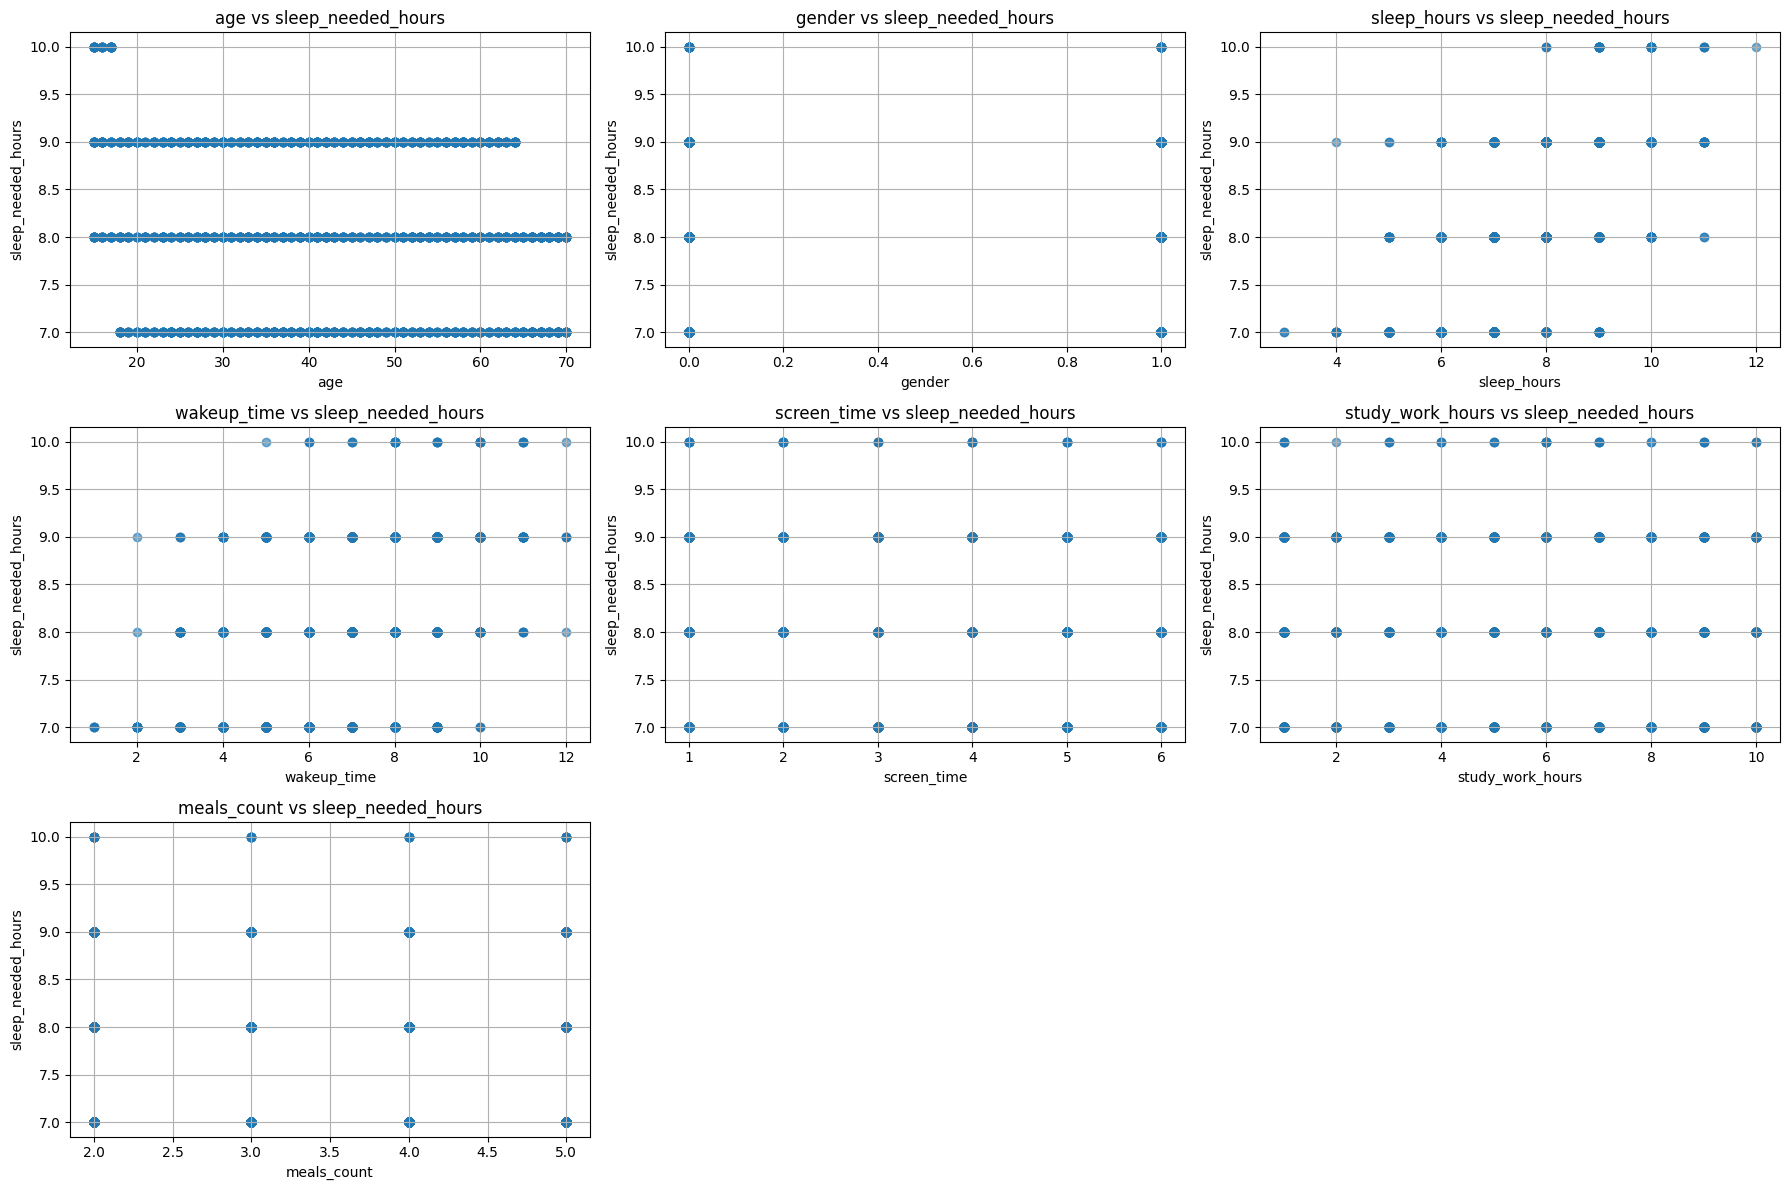

In [27]:
import matplotlib.pyplot as plt

features = ['age', 'gender', 'sleep_hours', 'wakeup_time', 'screen_time', 'study_work_hours', 'meals_count']
x_labels = ['age', 'gender', 'sleep_hours', 'wakeup_time', 'screen_time', 'study_work_hours', 'meals_count']
titles = ['age vs sleep_needed_hours', 
          'gender vs sleep_needed_hours', 
          'sleep_hours vs sleep_needed_hours', 
          'wakeup_time vs sleep_needed_hours', 
          'screen_time vs sleep_needed_hours',
          'study_work_hours vs sleep_needed_hours',
          'meals_count vs sleep_needed_hours']

Z = SAD['sleep_needed_hours']

plt.figure(figsize=(18,12)) 
for i, feature in enumerate(features):
    plt.subplot(3, 3, i+1)  
    plt.scatter(SAD[feature], Z, alpha=0.6) 
    plt.xlabel(x_labels[i])
    plt.ylabel("sleep_needed_hours")
    plt.title(titles[i])
    plt.grid(True)
plt.tight_layout()
plt.show()

           

In [28]:
lin_regg.fit(X_train, Z_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [29]:
lin_regg_train_prediction = lin_regg.predict(X_train)
print(lin_regg_train_prediction)

[7.54463405 7.41597415 7.46485907 ... 7.45737303 9.37551841 7.5337975 ]


In [30]:
lin_regg_test_prediction = lin_regg.predict(X_test)
print(lin_regg_test_prediction)

[7.39880812 7.94807001 7.87186323 8.31993818 7.54036351 8.18233079
 8.64545225 8.74344158 7.51209253 7.87655109 8.81956088 7.70666542
 7.77854513 9.11402203 8.32287449 8.35092362 8.0659721  7.88758753
 8.56589316 8.0782485  8.2992299  7.90489346 9.20417857 7.92721052
 8.62840466 8.3105106  8.6487541  7.91572908 8.44545005 7.90047985
 7.92314168 8.31816175 8.39110626 9.91609284 8.2007854  8.25069288
 8.72805526 8.08312527 8.74656256 8.58165207 7.65864825 9.06771573
 7.10551374 7.06425306 8.07604859 8.07938114 7.65762358 7.77631427
 8.183863   7.38386687 8.08826337 8.24426894 7.85815788 7.2772479
 7.84222013 8.69217507 7.77578565 7.19504418 7.09806038 7.39825385
 7.79661237 8.5224196  8.4737394  8.24107738 8.16118831 8.65503207
 8.57704163 8.54436696 7.50745221 8.00751672 7.01804505 8.51304259
 7.78844768 7.54175247 7.70046131 7.62281279 8.70456184 7.11332951
 7.50766691 7.73706367 7.331723   8.8903093  7.57207613 8.07162596
 7.45608637 7.36148436 8.78312926 7.59044258 7.53591103 8.28245

In [31]:
lin_regg_prediction = lin_regg.predict(np.array([[46 , 1, 11 , 3 , 4 , 10 , 5]]))
print(lin_regg_prediction)

[9.24728218]


In [32]:
X_test_logprediction = log_regg.predict(X_test)
X_test_navprediction = nav_b.predict(X_test)
X_test_ranprediction = ran_f.predict(X_test)
X_test_svmprediction = svm.predict(X_test)



In [33]:
from sklearn.metrics import confusion_matrix

cm_log = confusion_matrix(Y_test, X_test_logprediction)
print("Logistic Regression Confusion Matrix:\n", cm_log)

cm_nb = confusion_matrix(Y_test, X_test_navprediction)
print("Naive Bayes Confusion Matrix:\n", cm_nb)

cm_rf = confusion_matrix(Y_test, X_test_ranprediction)
print("Random Forest Confusion Matrix:\n", cm_rf)

cm_svm = confusion_matrix(Y_test, X_test_svmprediction)
print("SVM Confusion Matrix:\n", cm_svm)


Logistic Regression Confusion Matrix:
 [[285  13]
 [ 42  60]]
Naive Bayes Confusion Matrix:
 [[288  10]
 [ 38  64]]
Random Forest Confusion Matrix:
 [[279  19]
 [ 28  74]]
SVM Confusion Matrix:
 [[286  12]
 [ 35  67]]
